# Decision Tree Regressor

In [34]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
df = load_diabetes(as_frame=True).frame

In [16]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [31]:
df.shape

(442, 11)

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

# Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,  test_size=0.2, random_state=42
)

# Train Regression Model (Decision Tree)

In [70]:
from sklearn.tree import DecisionTreeRegressor
model  = DecisionTreeRegressor(max_depth=5, min_samples_split=20)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_split=20)

In [71]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluation metrics

In [72]:
print("MSE train  :- ",mean_squared_error(y_train,y_pred_train))
print("MSE test :- ",mean_squared_error(y_test,y_pred_test ))


print("MAE train  :- ",mean_absolute_error(y_train,y_pred_train))
print("MAE test :- ",mean_absolute_error(y_test,y_pred_test ))


print("r2 train  :- ",r2_score(y_train,y_pred_train))
print("r2 test :- ",r2_score(y_test,y_pred_test))

MSE train  :-  2132.340858311381
MSE test :-  3358.6384323271955
MAE train  :-  37.13047804930879
MAE test :-  45.3901384571238
r2 train  :-  0.6490781456786083
r2 test :-  0.36607356834058946


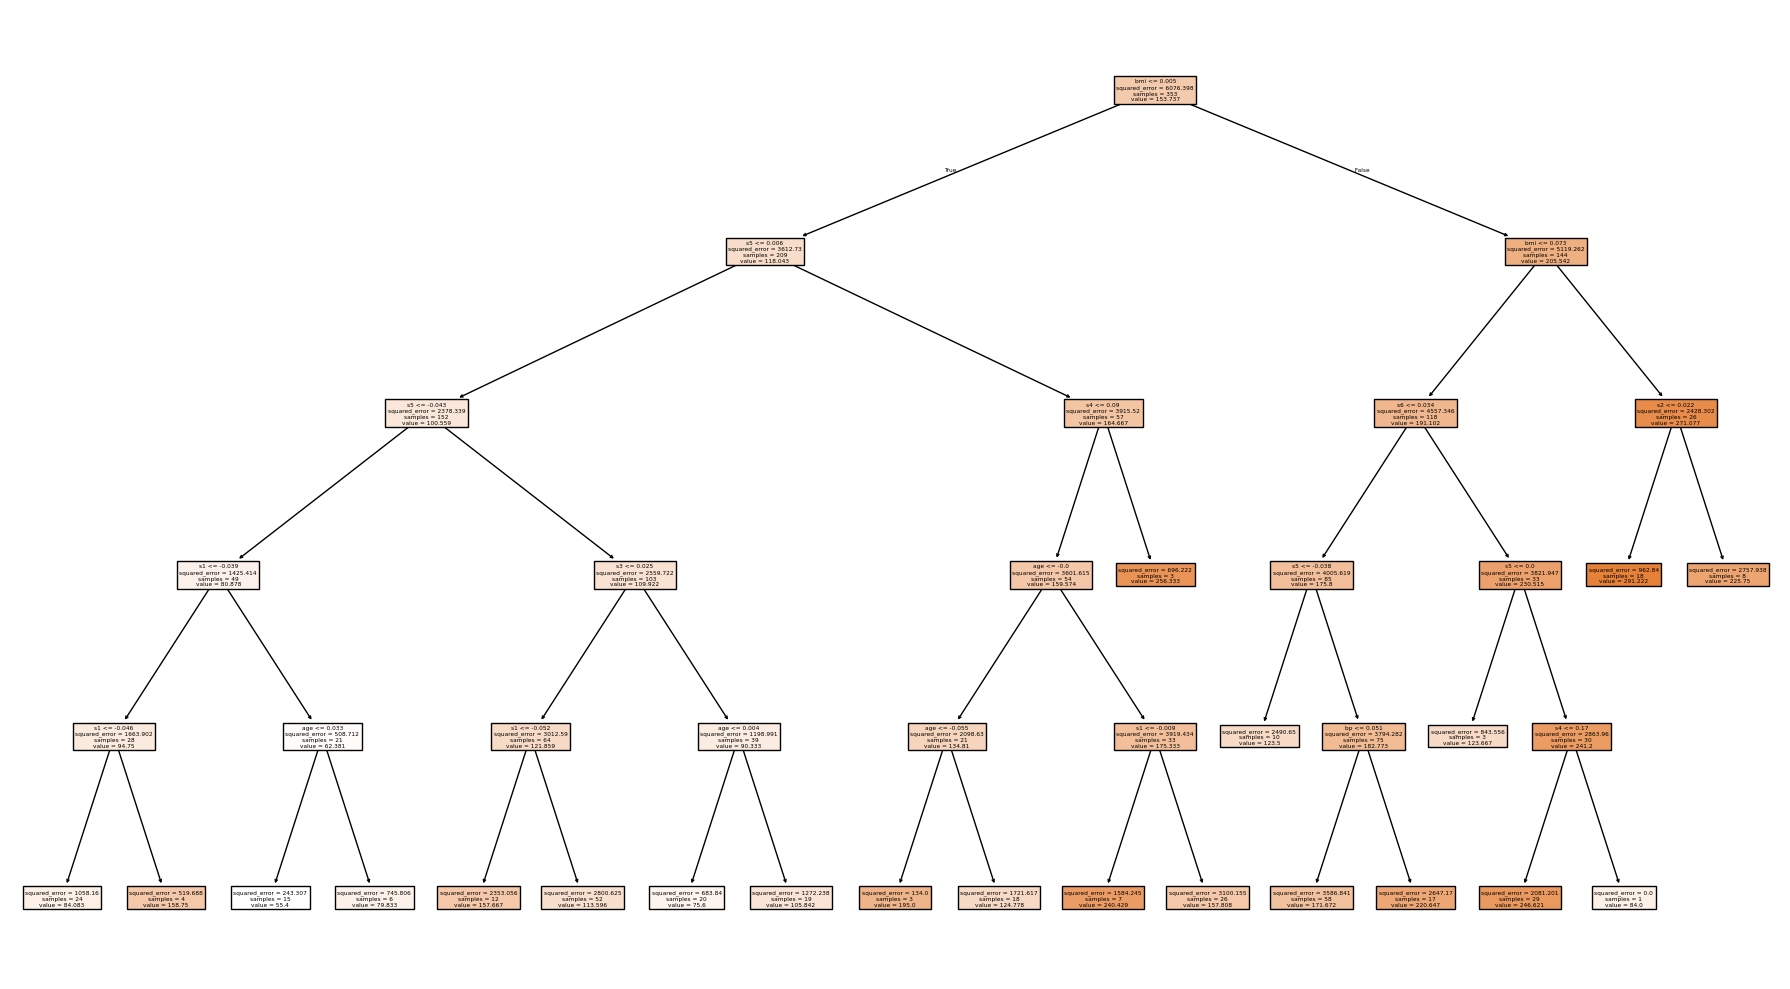

In [73]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    # max_depth=1
    
)
plt.tight_layout()